# Notebook 5 — Sensitivity to the SAVI binarization threshold

The vegetation-response outcome (`Effective`) is defined by binarizing the
up-/down-slope SAVI **percent difference** (`effect_percent`) at a single cut-off.
Notebooks 1–2 use **7 %**: a berm shows a *vegetation response* when
`effect_percent > 7`.

This notebook asks **how sensitive the main results are to that 7 % choice.**
We sweep the threshold from **0 % to 10 % in 1 % increments** and, for each value,
regenerate **Figure 8** (Intact × vegetation-response co-occurrence, and vegetation
response by soil texture & condition) together with its key statistics.

All inputs come from `data/merged.csv`, which already carries the continuous
`effect_percent`; only the binarization step is repeated per threshold.

In [1]:
import sys as _sys
_sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import pearsonr, fisher_exact, chi2_contingency

from constants import (
    INTACT_COL, DEGRADED_COL,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE,
    FS,
)

pd.set_option('display.max_columns', 50)

In [2]:
# ── Data + sweep configuration ───────────────────────────────────────────────
data = pd.read_csv('../data/merged.csv')

# Threshold sweep: SAVI percent-difference cut-offs, 0 → 10 % in 1 % steps.
THRESHOLDS = list(range(0, 11))
BASELINE_T = 7          # value used in notebooks 1–2

# Directory for the per-threshold Figure 8 renders.
SENS_DIR = Path('../figures/sensitivity')
SENS_DIR.mkdir(parents=True, exist_ok=True)

print(f"{len(data)} berm rows; sweeping thresholds {THRESHOLDS} (baseline = {BASELINE_T}%).")

775 berm rows; sweeping thresholds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (baseline = 7%).


## Reusable Figure 8 builder

`binarize()` re-derives the `Effective` label for an arbitrary threshold, and
`draw_fig8()` reproduces the two-panel figure exactly as in notebook 2 — but
parameterized by the threshold so we can call it once per sweep value. Both
functions read the continuous `effect_percent` and depend on nothing that was
binarized upstream.

In [3]:
def binarize(df, t):
    '''Return a copy of *df* with the `Effective` label recomputed at cut-off *t*
    (a berm shows a vegetation response when effect_percent > t).'''
    d = df.copy()
    d['Effective'] = np.where(d['effect_percent'] > t, LBL_EFFECTIVE, LBL_INEFFECTIVE)
    return d


def fig8_stats(df, t, n_textures=3):
    '''Compute the statistics behind both Figure 8 panels at threshold *t*.

    Returns a dict with the Panel-A crosstab / phi / p and a tidy Panel-B table
    (per texture × condition: n, eff_count, proportion, per-texture Fisher p).'''
    d = binarize(df, t)

    # Panel A — Intact × vegetation-response co-occurrence
    va = d.dropna(subset=['Intact', 'effect_percent']).copy()
    va['_int'] = va['Intact'].astype(bool).astype(int)
    va['_eff'] = (va['Effective'] == LBL_EFFECTIVE).astype(int)
    ct = (pd.crosstab(va['_int'], va['_eff'])
            .reindex(index=[0, 1], columns=[0, 1], fill_value=0))
    if va['_int'].nunique() < 2 or va['_eff'].nunique() < 2:
        phi, p_phi = np.nan, np.nan          # a constant outcome has no correlation
    else:
        phi, p_phi = pearsonr(va['_int'], va['_eff'])

    # Panel B — vegetation response by texture & condition (top-N textures)
    sub = d.dropna(subset=['Texture', 'Effective', 'effect_percent']).copy()
    sub['_eff'] = (sub['Effective'] == LBL_EFFECTIVE).astype(int)
    top = sub['Texture'].value_counts().head(n_textures).index.tolist()
    rows = []
    for tex in top:
        gt = sub[sub['Texture'] == tex]
        ctt = (pd.crosstab(gt['Condition'], gt['_eff'])
                 .reindex(index=['Degraded', 'Intact'], columns=[0, 1], fill_value=0))
        _, p_tex = fisher_exact(ctt.values) if ctt.values.sum() else (np.nan, np.nan)
        for cond in ['Intact', 'Degraded']:
            g = gt[gt['Condition'] == cond]
            rows.append({'threshold': t, 'Texture': tex, 'Condition': cond,
                         'n': len(g), 'eff_count': int(g['_eff'].sum()),
                         'prop': g['_eff'].mean() if len(g) else np.nan,
                         'p_tex': p_tex})
    return {'threshold': t, 'crosstab': ct, 'phi': phi, 'p_phi': p_phi,
            'top_textures': top, 'panelB': pd.DataFrame(rows)}


def draw_fig8(df, t, fig=None, save=False):
    '''Reproduce the two-panel Figure 8 at threshold *t*. Returns (fig, stats).'''
    st = fig8_stats(df, t)
    ct, phi, p_phi = st['crosstab'], st['phi'], st['p_phi']
    pB, top = st['panelB'], st['top_textures']

    if fig is None:
        fig = plt.figure(figsize=(15, 5.5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.30, figure=fig)
    ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    # ── Panel A: 2×2 co-occurrence heatmap ──────────────────────────────────
    arr = ct.values
    arr_pct = (ct / arr.sum() * 100).round(1).values
    ax1.imshow(arr, cmap=plt.cm.Blues, vmin=0, vmax=arr.max() * 1.35, aspect='auto')
    for i in range(2):
        for j in range(2):
            tc = 'white' if arr[i, j] > arr.max() * 0.55 else 'black'
            ax1.text(j, i, f"{arr[i, j]}\n({arr_pct[i, j]:.1f}%)", ha='center',
                     va='center', fontsize=FS, fontweight='bold', color=tc)
    for i, j in [(0, 1), (1, 0)]:                        # discordant cells
        ax1.add_patch(plt.Rectangle((j - 0.48, i - 0.48), 0.96, 0.96, fill=False,
                                    edgecolor='tomato', linewidth=2.2, zorder=5))
    ax1.set_xticks([0, 1]); ax1.set_xticklabels(['No response', 'Vegetation\nresponse'], fontsize=FS)
    ax1.set_yticks([0, 1]); ax1.set_yticklabels(['Degraded', 'Intact'], fontsize=FS)
    ax1.set_xlabel('Vegetation response', fontsize=FS)
    ax1.set_ylabel('Condition', fontsize=FS)
    p_str = f"p = {p_phi:.3f}" if p_phi >= 0.001 else "p < 0.001"
    assoc = 'no significant association' if not (p_phi <= 0.05) else 'significant'
    ax1.set_title(f"A  |  Intact × Vegetation response co-occurrence  (>{t}%)\n"
                  f"φ = {phi:.2f}  ({p_str};  {assoc})",
                  fontsize=FS, fontweight='bold', loc='left', pad=14)

    # ── Panel B: grouped horizontal barplot ─────────────────────────────────
    tex_order = [x for x in texture_order if x in top] + [x for x in top if x not in texture_order]
    y = np.arange(len(tex_order)); bw = 0.35
    for idx, (grp, color) in enumerate({'Intact': INTACT_COL, 'Degraded': DEGRADED_COL}.items()):
        gdf = pB[pB['Condition'] == grp].set_index('Texture')
        vals = [gdf.loc[x, 'prop'] if x in gdf.index else 0 for x in tex_order]
        cnts = [int(gdf.loc[x, 'eff_count']) if x in gdf.index else 0 for x in tex_order]
        off = -bw / 2 if idx == 0 else bw / 2
        bars = ax2.barh(y + off, vals, bw, label=grp, color=color,
                        edgecolor='black', linewidth=0.7)
        for b, c in zip(bars, cnts):
            ax2.text(b.get_width() + 0.01, b.get_y() + b.get_height() / 2,
                     f"n={c}", va='center', fontsize=FS, color='#333333')
    for j, tex in enumerate(tex_order):                  # per-texture Fisher p
        ri = pB[(pB['Texture'] == tex) & (pB['Condition'] == 'Intact')]
        rd = pB[(pB['Texture'] == tex) & (pB['Condition'] == 'Degraded')]
        if ri.empty or rd.empty:
            continue
        p_tex = ri['p_tex'].values[0]
        if p_tex < 0.05:
            top_v = max(ri['prop'].values[0], rd['prop'].values[0])
            ax2.text(top_v + 0.12, j, f"p={p_tex:.3f}*", va='center',
                     fontsize=FS, color='#333333')
    ax2.set_yticks(y); ax2.set_yticklabels(tex_order, fontsize=FS)
    ax2.set_xlabel('Proportion with vegetation response', fontsize=FS)
    ax2.set_xlim(0, 1.15); ax2.invert_yaxis()
    ax2.axvline(0.5, color='#cccccc', linewidth=0.8, linestyle='--')
    ax2.legend(title='Condition', fontsize=FS, title_fontsize=FS)
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.tick_params(axis='x', labelsize=FS)
    ax2.set_title(f"B  |  Vegetation response by soil texture & condition  (>{t}%)\n",
                  fontsize=FS, fontweight='bold', loc='left', pad=14)

    if save:
        out = SENS_DIR / f"fig8_threshold_{t:02d}pct.png"
        fig.savefig(out, dpi=200, bbox_inches='tight')
    return fig, st

## Sanity check — Figure 8 at the baseline 7 % threshold

This should match the published Figure 8: φ ≈ −0.02 (p = 0.612), cells
163 / 154 / 244 / 214, and a significant sandy-loam contrast (p = 0.034).

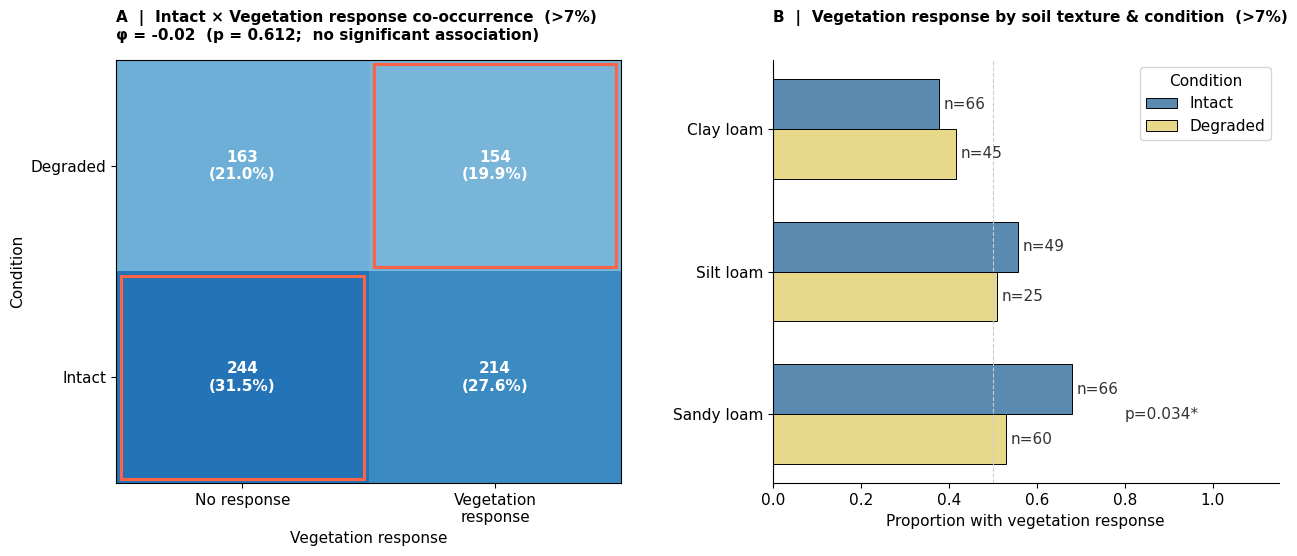

crosstab (rows Degraded/Intact, cols No-response/Response):
[[163 154]
 [244 214]]


In [4]:
fig, st = draw_fig8(data, BASELINE_T)
plt.show()
print("crosstab (rows Degraded/Intact, cols No-response/Response):")
print(st['crosstab'].values)

## Threshold sweep — collect Figure 8 statistics

For every threshold we record the Panel-A association (φ, p) and, for each of
the top-3 textures, the intact/degraded vegetation-response proportions and the
per-texture Fisher p-value.

In [5]:
panelA_rows, panelB_frames = [], []
for t in THRESHOLDS:
    st = fig8_stats(data, t)
    ct = st['crosstab']
    n = ct.values.sum()
    panelA_rows.append({
        'threshold': t,
        'phi': st['phi'],
        'p_phi': st['p_phi'],
        'sig_A': (st['p_phi'] <= 0.05),
        'prevalence': (ct.loc[0, 1] + ct.loc[1, 1]) / n,   # overall % veg response
        'n': int(n),
    })
    panelB_frames.append(st['panelB'])

sweepA = pd.DataFrame(panelA_rows)
sweepB = pd.concat(panelB_frames, ignore_index=True)

display(sweepA.round(3))

,threshold,phi,p_phi,sig_A,prevalence,n
0,0,-0.040,0.270,False,0.668,775
1,1,-0.035,0.337,False,0.643,775
2,2,-0.037,0.303,False,0.622,775
3,3,-0.049,0.169,False,0.592,775
4,4,-0.016,0.647,False,0.555,775
5,5,-0.027,0.455,False,0.526,775
6,6,-0.018,0.626,False,0.494,775
7,7,-0.018,0.612,False,0.475,775
8,8,-0.029,0.426,False,0.453,775
9,9,-0.029,0.428,False,0.431,775


In [6]:
# Per-texture Fisher p across thresholds (one row per threshold, one col per texture).
pivot_p = (sweepB.drop_duplicates(['threshold', 'Texture'])
                 .pivot(index='threshold', columns='Texture', values='p_tex'))
print("Per-texture Fisher p-value vs threshold (bold-worthy where < 0.05):")
display(pivot_p.round(3))

Per-texture Fisher p-value vs threshold (bold-worthy where < 0.05):


Texture,Clay loam,Sandy loam,Silt loam
threshold,,,
0,0.266,0.214,1.000
1,0.540,0.221,1.000
2,0.392,0.182,1.000
3,0.330,0.256,1.000
4,0.460,0.062,0.590
5,0.323,0.076,0.858
6,0.454,0.045,0.721
7,0.533,0.034,0.721
8,0.447,0.126,0.594


## Panel A sensitivity — Intact × vegetation-response association

Does the "structural condition and vegetation response are independent"
conclusion survive the threshold choice?

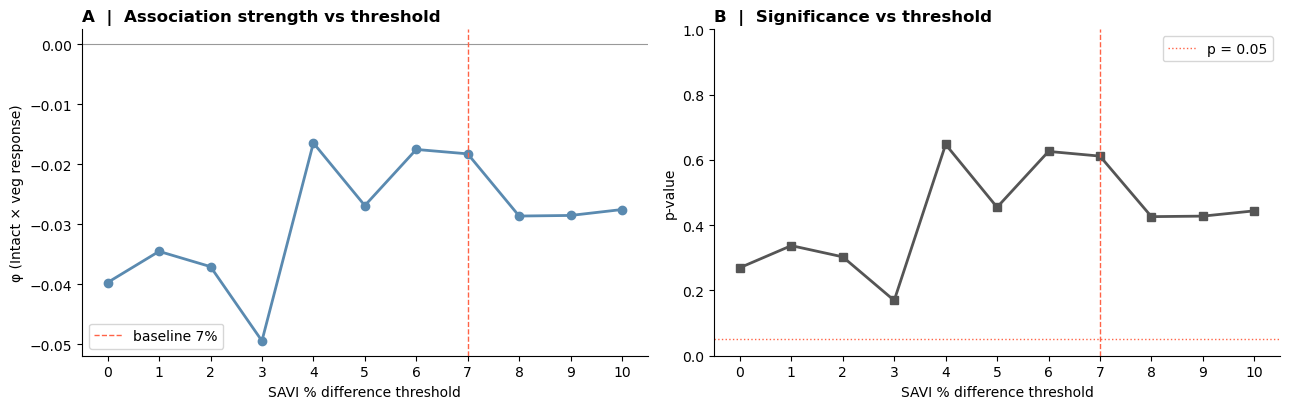

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))

axL.axhline(0, color='#999999', lw=0.8)
axL.plot(sweepA['threshold'], sweepA['phi'], 'o-', color=INTACT_COL, lw=2)
axL.axvline(BASELINE_T, color='tomato', ls='--', lw=1, label=f'baseline {BASELINE_T}%')
axL.set_xlabel('SAVI % difference threshold'); axL.set_ylabel('φ (Intact × veg response)')
axL.set_title('A  |  Association strength vs threshold', fontweight='bold', loc='left')
axL.set_xticks(THRESHOLDS); axL.legend(); axL.spines[['top', 'right']].set_visible(False)

axR.axhline(0.05, color='tomato', ls=':', lw=1, label='p = 0.05')
axR.plot(sweepA['threshold'], sweepA['p_phi'], 's-', color='#555555', lw=2)
axR.axvline(BASELINE_T, color='tomato', ls='--', lw=1)
axR.set_ylim(0, 1); axR.set_xlabel('SAVI % difference threshold'); axR.set_ylabel('p-value')
axR.set_title('B  |  Significance vs threshold', fontweight='bold', loc='left')
axR.set_xticks(THRESHOLDS); axR.legend(); axR.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(SENS_DIR / 'fig8_panelA_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

## Panel B sensitivity — vegetation response by texture & condition

Left: intact vs degraded vegetation-response proportion per texture, as the
threshold moves. Right: the per-texture Fisher p-value; points below the dotted
line are significant. This shows how robust the sandy-loam contrast is.

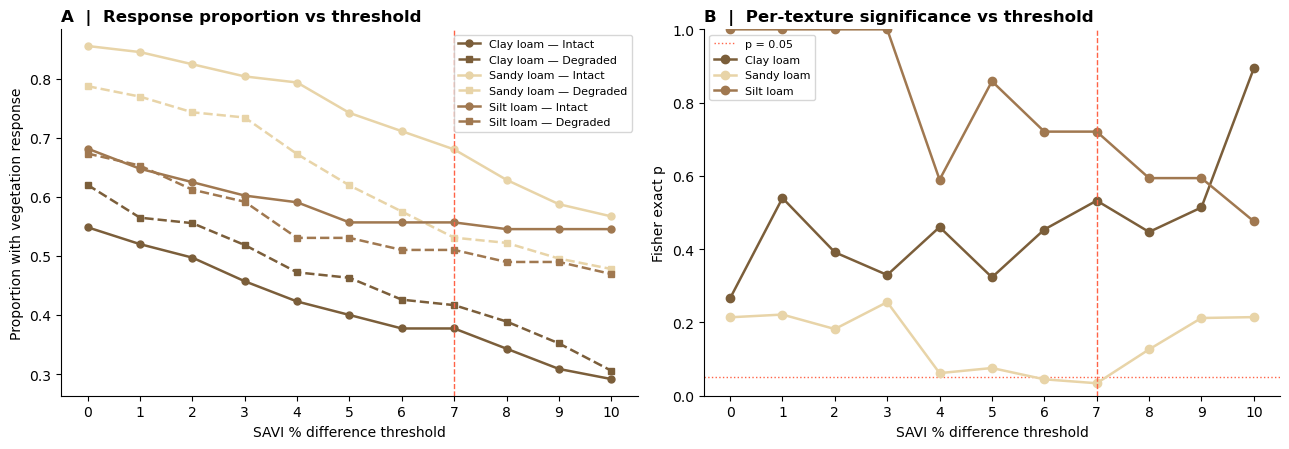

In [8]:
top_textures = sweepB.drop_duplicates('Texture')['Texture'].tolist()
tex_colors = {t: TEXTURE_COLORS.get(t, f'C{i}') for i, t in enumerate(top_textures)}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))

for tex in top_textures:
    c = tex_colors[tex]
    for cond, ls, mk in [('Intact', '-', 'o'), ('Degraded', '--', 's')]:
        s = sweepB[(sweepB['Texture'] == tex) & (sweepB['Condition'] == cond)]
        axL.plot(s['threshold'], s['prop'], ls, marker=mk, color=c,
                 label=f'{tex} — {cond}', lw=1.8, ms=5)
axL.axvline(BASELINE_T, color='tomato', ls='--', lw=1)
axL.set_xlabel('SAVI % difference threshold')
axL.set_ylabel('Proportion with vegetation response')
axL.set_title('A  |  Response proportion vs threshold', fontweight='bold', loc='left')
axL.set_xticks(THRESHOLDS)
axL.legend(fontsize=8, ncol=1, loc='upper right')
axL.spines[['top', 'right']].set_visible(False)

axR.axhline(0.05, color='tomato', ls=':', lw=1, label='p = 0.05')
for tex in top_textures:
    s = sweepB.drop_duplicates(['threshold', 'Texture'])
    s = s[s['Texture'] == tex]
    axR.plot(s['threshold'], s['p_tex'], 'o-', color=tex_colors[tex], lw=1.8, label=tex)
axR.axvline(BASELINE_T, color='tomato', ls='--', lw=1)
axR.set_ylim(0, 1); axR.set_xlabel('SAVI % difference threshold'); axR.set_ylabel('Fisher exact p')
axR.set_title('B  |  Per-texture significance vs threshold', fontweight='bold', loc='left')
axR.set_xticks(THRESHOLDS); axR.legend(fontsize=8)
axR.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(SENS_DIR / 'fig8_panelB_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary — how robust is Figure 8?

**Panel A (structural condition × vegetation response) is robust.** φ stays within
≈ ±0.05 of zero and is non-significant (p ≈ 0.17 – 0.65) at every threshold from
0 % to 10 %. The conclusion that structural integrity and vegetation response are
statistically independent does **not** depend on the 7 % cut-off.

**Panel B (sandy-loam contrast) is fragile.** The intact-vs-degraded difference in
sandy-loam vegetation response is significant only in a narrow band around the
baseline (Fisher p = 0.045 at 6 %, 0.034 at 7 %; marginal at 4–5 %; non-significant
elsewhere). Clay loam and silt loam are never significant. This result should be
reported as **threshold-sensitive**.

## Figure 8 rendered at every threshold

The full two-panel figure regenerated for each cut-off from 0 % to 10 %.
Each render is also saved to `figures/sensitivity/fig8_threshold_XXpct.png`.

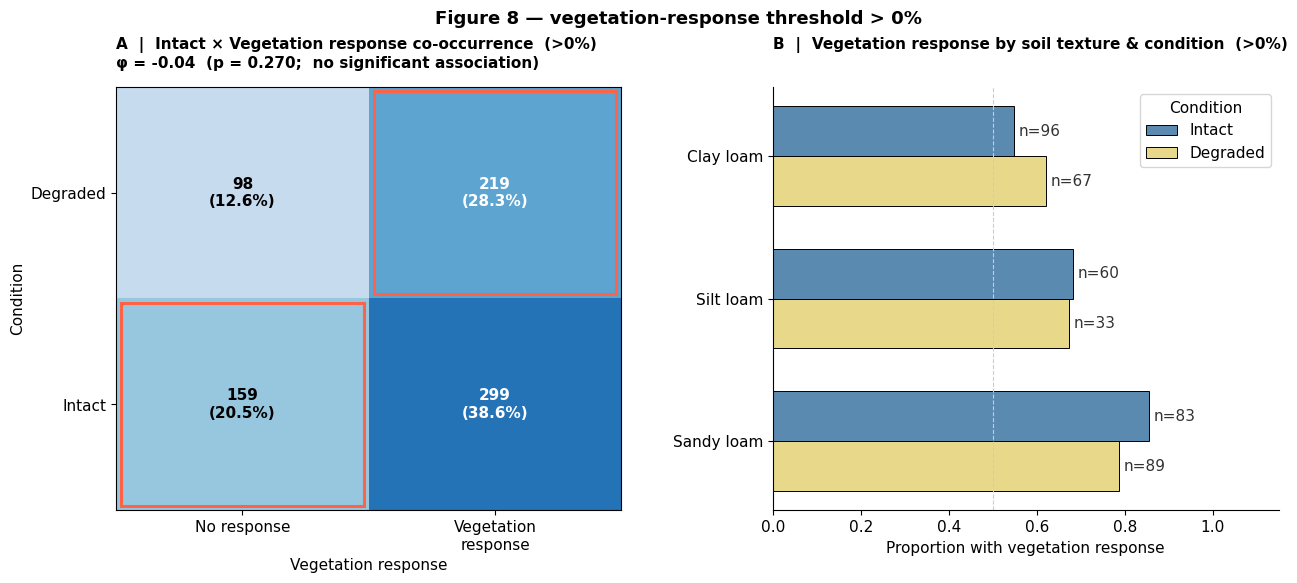

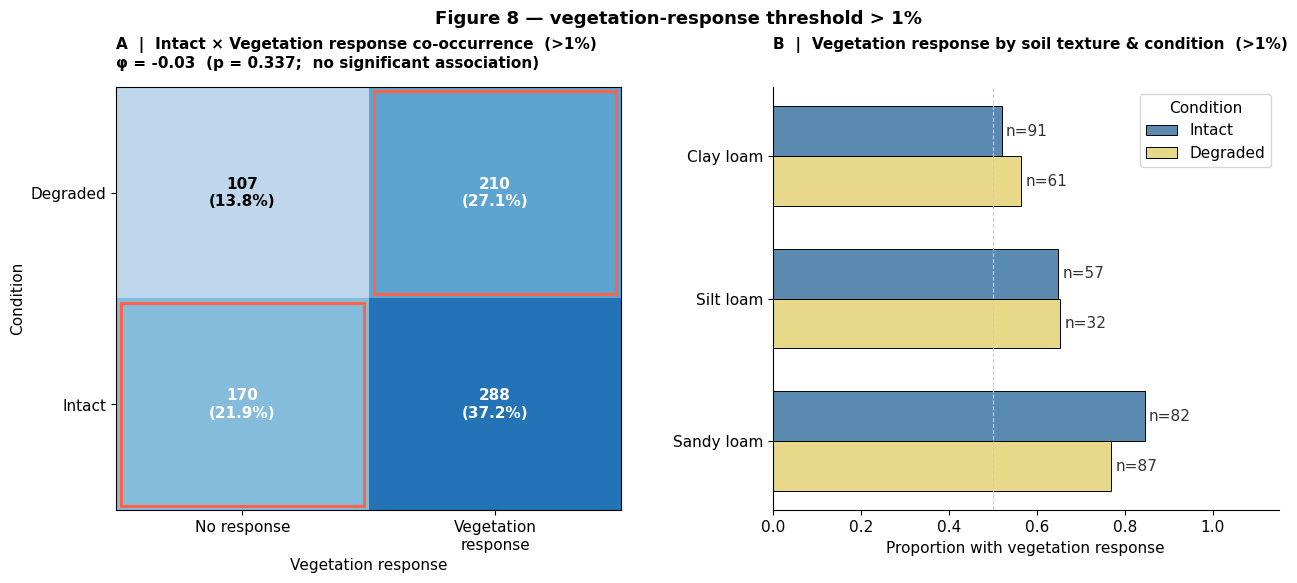

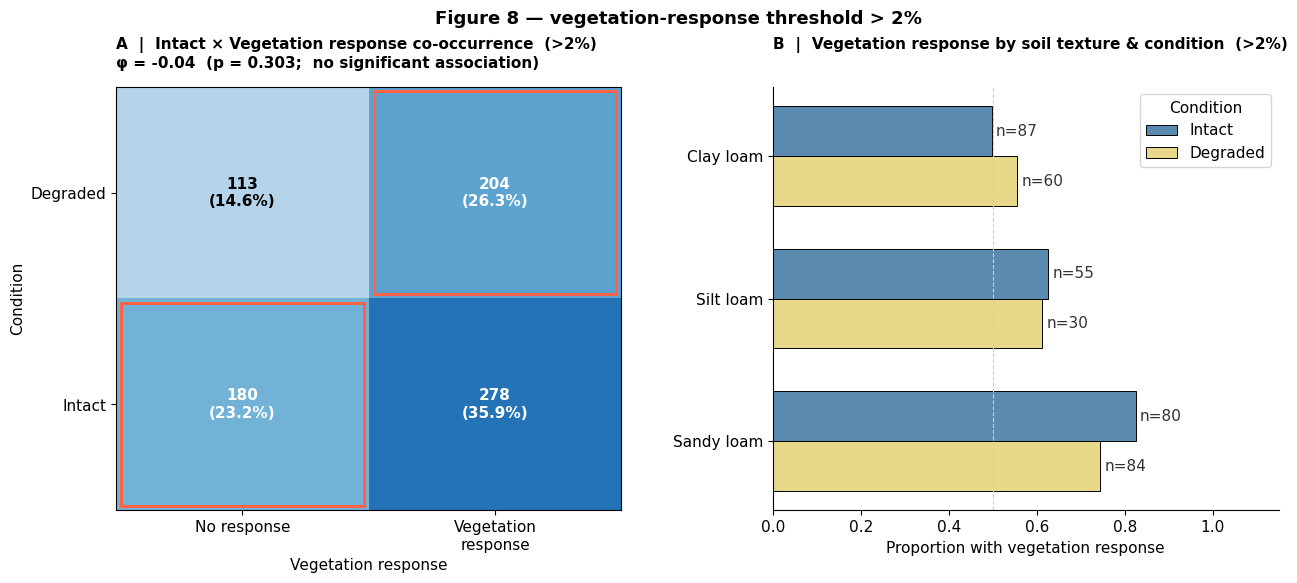

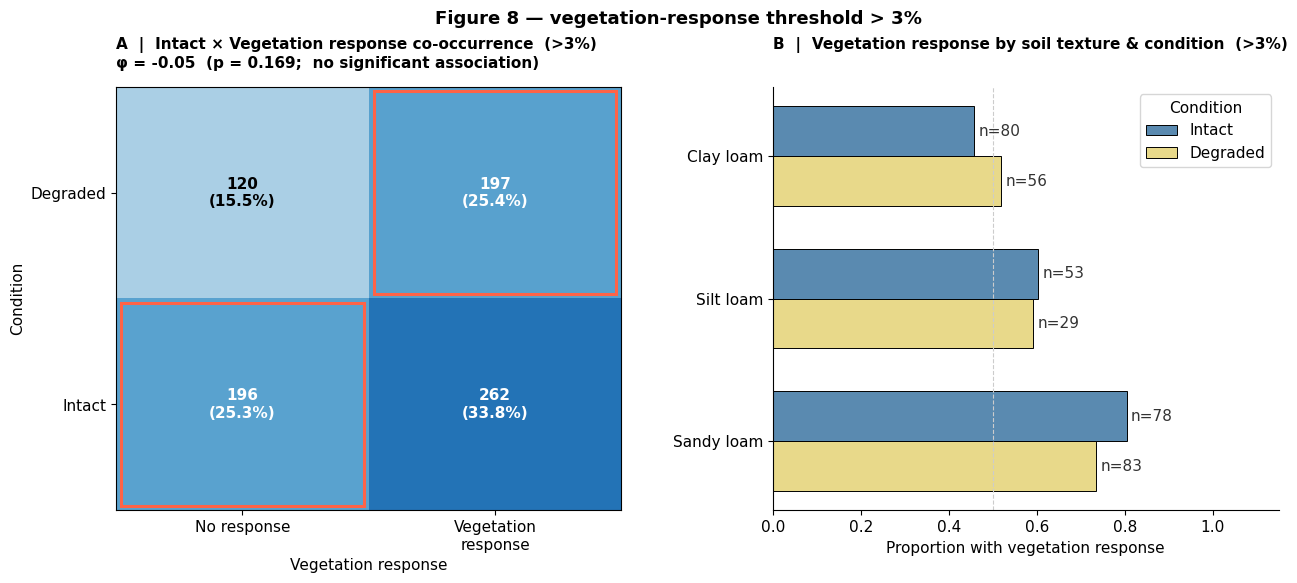

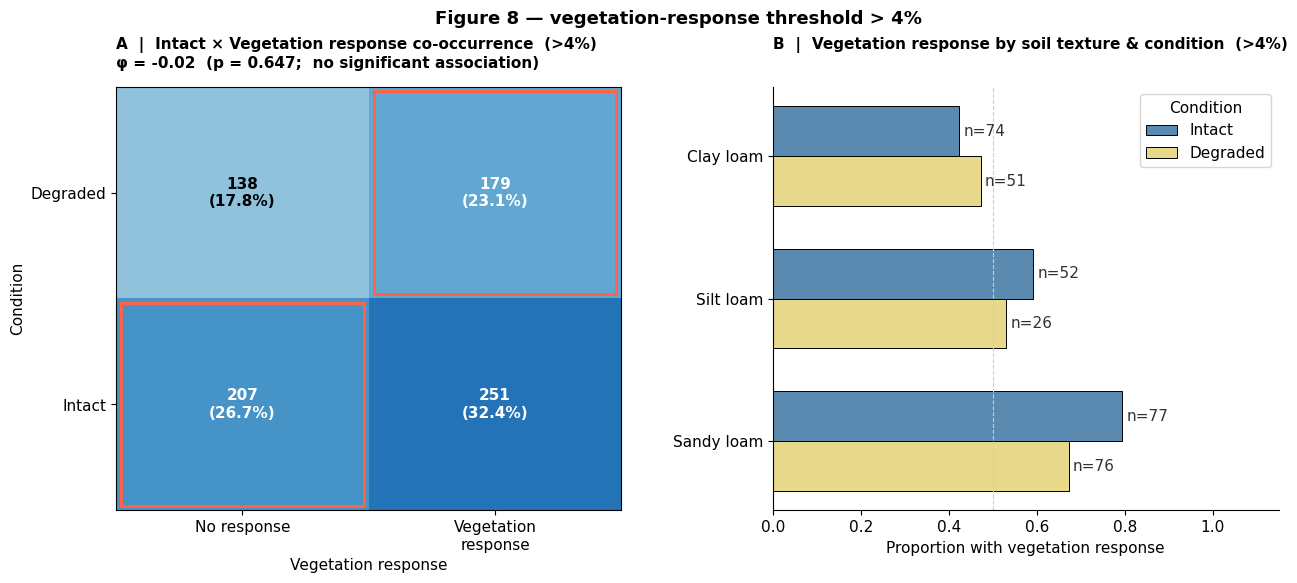

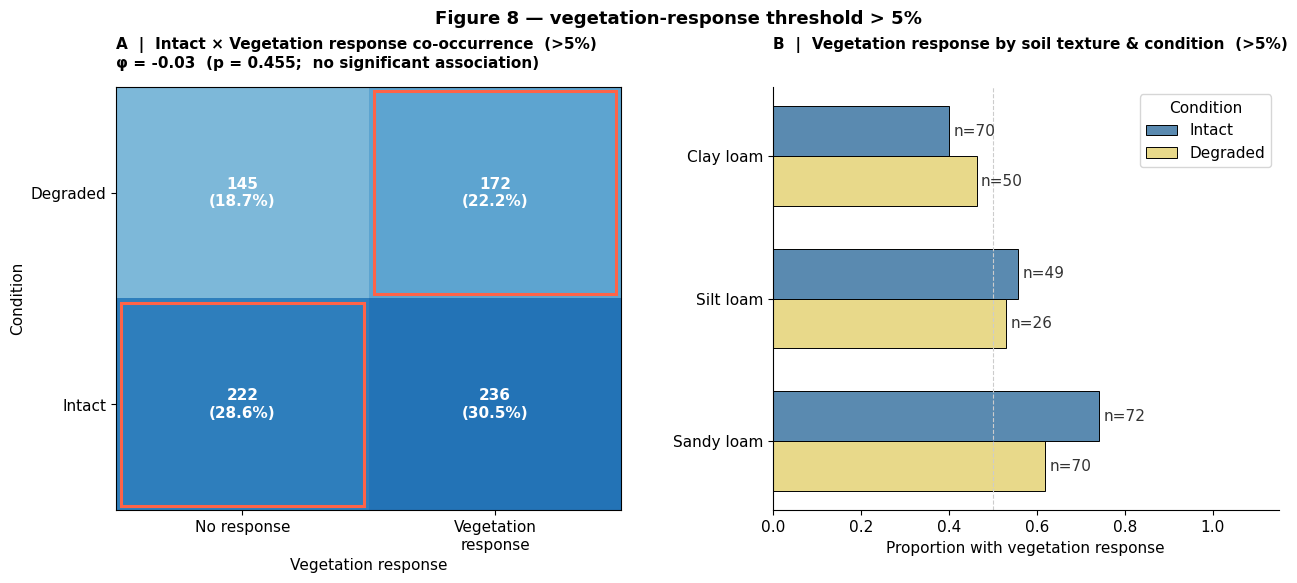

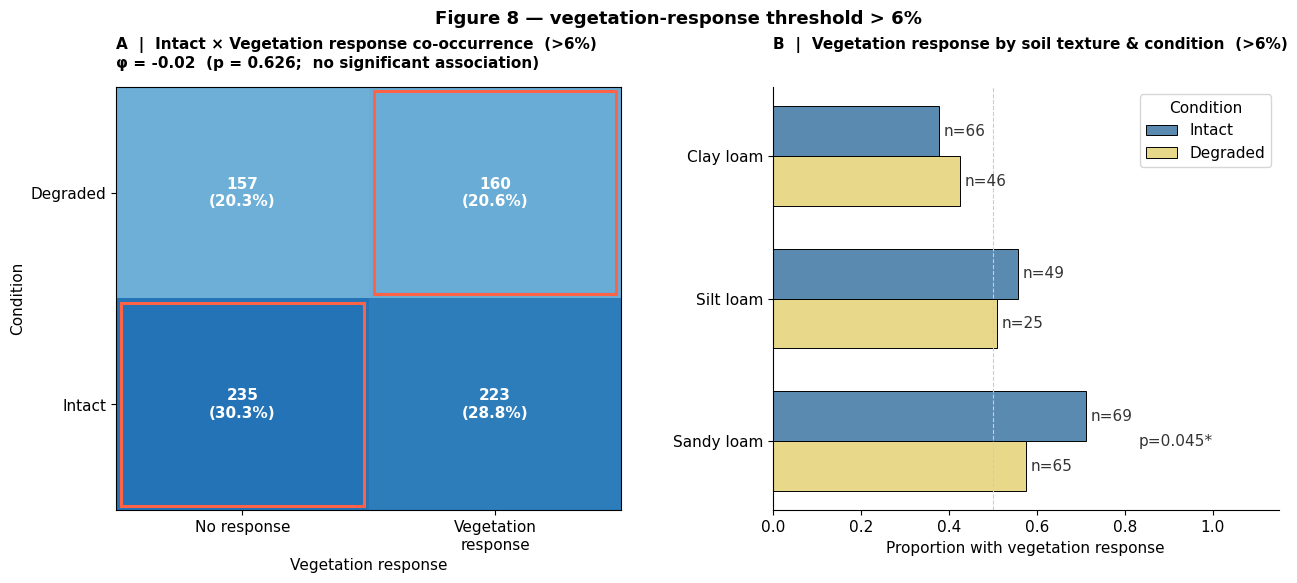

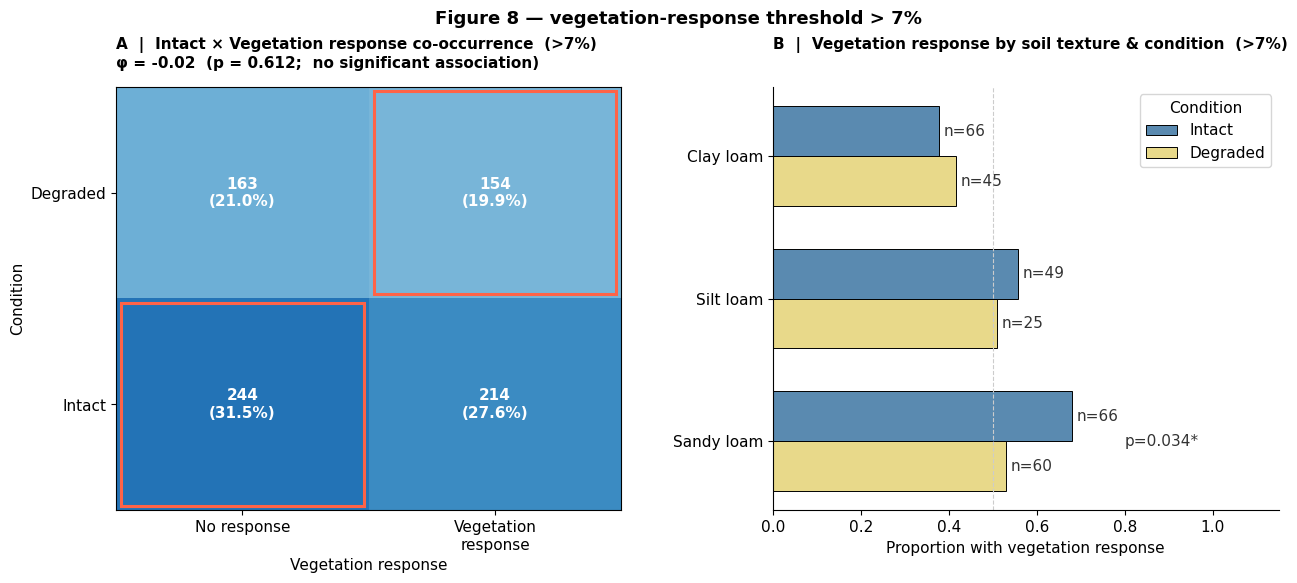

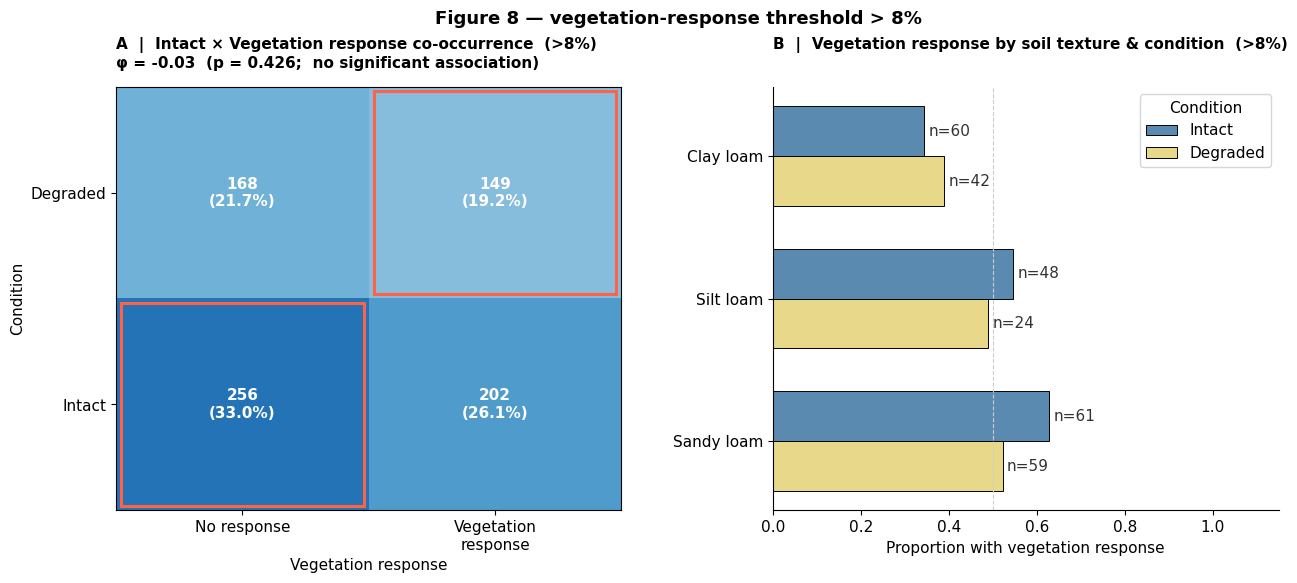

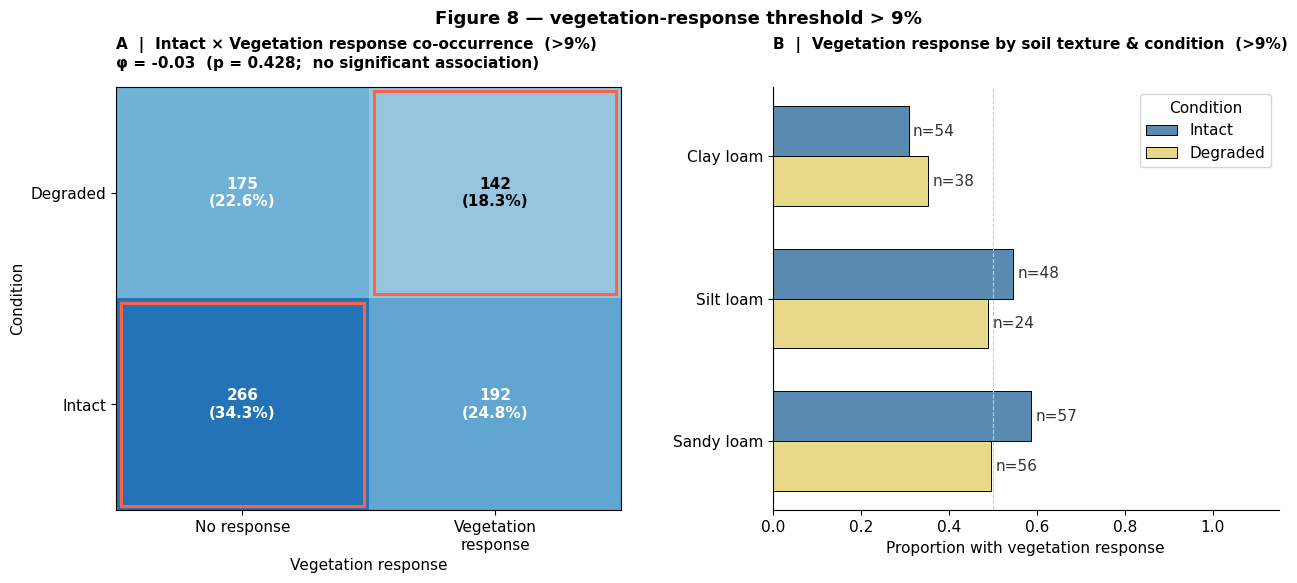

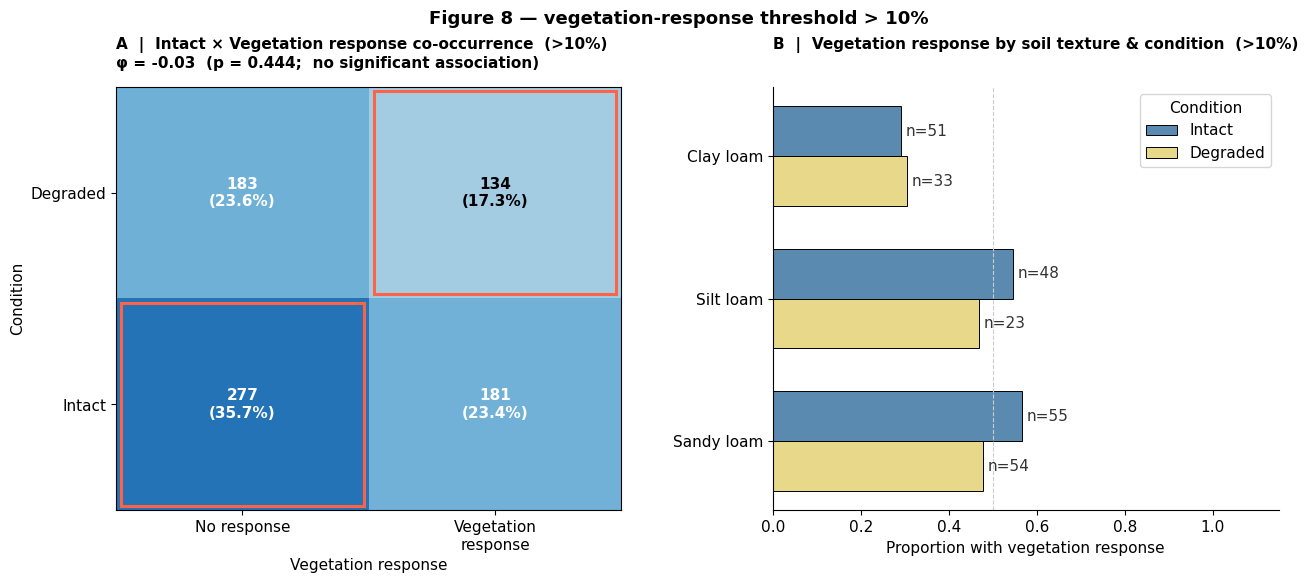

Saved 11 renders to ../figures/sensitivity/


In [9]:
for t in THRESHOLDS:
    fig, st = draw_fig8(data, t, save=True)
    fig.suptitle(f"Figure 8 — vegetation-response threshold > {t}%",
                 fontsize=FS + 2, fontweight='bold', y=1.02)
    plt.show()
    plt.close(fig)
print(f"Saved {len(THRESHOLDS)} renders to {SENS_DIR}/")

## Figure 7 sensitivity — predictors of vegetation response

Figure 8 is not the only result built on the SAVI threshold: **Figure 7** tests
six predictors against the same binarized vegetation-response outcome. Here we
recompute each predictor's association p-value across the 0 – 10 % sweep —
two-sided **Fisher's exact** for the binary predictors (length, slope, B horizon,
flow accumulation) and a **chi-square** omnibus for the multi-category predictors
(landform, and soil-texture classes with n > 100). Flow accumulation is binarized
at the same 2 000-cell cut-off used in the figure, which is independent of the
SAVI threshold.

In [10]:
# Flow-accumulation class is fixed (independent of the SAVI threshold).
FA_OPT = 2000
data['FA_Class'] = np.where(data['FA_30_max'] >= FA_OPT, 'High FA', 'Low FA')

BINARY_PREDS = [('Berm length', 'Berm_Length_Class'),
                ('Slope class', 'Slope_Class'),
                ('B horizon', 'Soil_Development'),
                ('Flow accumulation', 'FA_Class')]
MULTI_PREDS = [('Landform', 'Landform', 0),
               ('Soil texture', 'Texture', 100)]     # min n per retained class


def _fisher_p(d, col):
    d = d.dropna(subset=[col, '_eff'])
    cats = d[col].dropna().unique()
    if len(cats) != 2:
        return np.nan
    a, b = cats
    ka, na = d.loc[d[col] == a, '_eff'].sum(), int((d[col] == a).sum())
    kb, nb = d.loc[d[col] == b, '_eff'].sum(), int((d[col] == b).sum())
    return fisher_exact([[ka, na - ka], [kb, nb - kb]])[1]


def _chi2_p(d, col, min_n):
    d = d.dropna(subset=[col, '_eff'])
    if min_n:
        keep = d[col].value_counts()
        keep = keep[keep > min_n].index
        d = d[d[col].isin(keep)]
    ct = pd.crosstab(d[col], d['_eff'])
    ct = ct[ct.sum(axis=1) > 0]
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    return chi2_contingency(ct)[1]


fig7_rows = []
for t in THRESHOLDS:
    d = data.copy()
    d['_eff'] = (d['effect_percent'] > t).astype(int)
    row = {'threshold': t}
    for name, col in BINARY_PREDS:
        row[name] = _fisher_p(d, col)
    for name, col, min_n in MULTI_PREDS:
        row[name] = _chi2_p(d, col, min_n)
    fig7_rows.append(row)

fig7_p = pd.DataFrame(fig7_rows).set_index('threshold')
print("Association p-value with vegetation response, by predictor × threshold:")
display(fig7_p.round(4))
print("\nSignificant (p < 0.05) at every threshold:",
      [c for c in fig7_p.columns if (fig7_p[c] < 0.05).all()])
print("Never significant:",
      [c for c in fig7_p.columns if (fig7_p[c] >= 0.05).all()])

Association p-value with vegetation response, by predictor × threshold:


,Berm length,Slope class,B horizon,Flow accumulation,Landform,Soil texture
threshold,,,,,,
0,0.1949,0.0,0.0000,0.0330,0.0000,0.0
1,0.2939,0.0,0.0000,0.0201,0.0000,0.0
2,0.5538,0.0,0.0000,0.0640,0.0000,0.0
3,0.3061,0.0,0.0000,0.0408,0.0000,0.0
4,0.4697,0.0,0.0000,0.0827,0.0000,0.0
5,0.2504,0.0,0.0000,0.1953,0.0000,0.0
6,0.6666,0.0,0.0000,0.0525,0.0000,0.0
7,0.5648,0.0,0.0008,0.0311,0.0004,0.0
8,0.9425,0.0,0.0010,0.0976,0.0002,0.0



Significant (p < 0.05) at every threshold: ['Slope class', 'B horizon', 'Landform', 'Soil texture']
Never significant: ['Berm length']


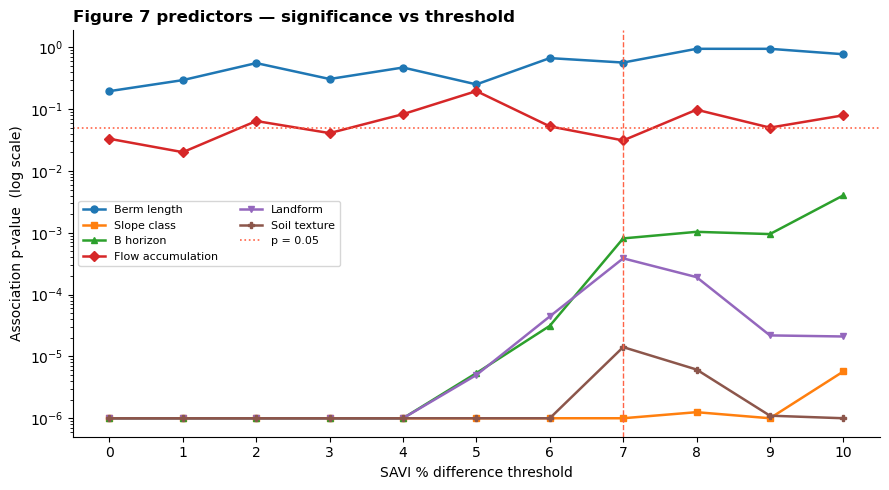

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'P']
for m, pred in zip(markers, fig7_p.columns):
    ax.plot(fig7_p.index, fig7_p[pred].clip(lower=1e-6),
            marker=m, lw=1.8, ms=5, label=pred)
ax.axhline(0.05, color='tomato', ls=':', lw=1.2, label='p = 0.05')
ax.axvline(BASELINE_T, color='tomato', ls='--', lw=1)
ax.set_yscale('log')
ax.set_xlabel('SAVI % difference threshold')
ax.set_ylabel('Association p-value  (log scale)')
ax.set_title('Figure 7 predictors — significance vs threshold',
             fontweight='bold', loc='left')
ax.set_xticks(THRESHOLDS)
ax.legend(fontsize=8, ncol=2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(SENS_DIR / 'fig7_predictor_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary — how robust is Figure 7?

- **Robust (significant at every threshold):** slope class, landform, soil texture,
  and B-horizon presence stay strongly significant (p ≪ 0.01) across the whole
  0 – 10 % range. Figure 7's headline associations do not depend on the cut-off.
- **Fragile:** flow accumulation hovers around p = 0.05 and flips significance
  depending on the threshold — report it as threshold-sensitive.
- **Never significant:** berm length.

Taken together with Figure 8, the threshold choice matters only for the two
weakest signals (the sandy-loam contrast and flow accumulation); every strong
conclusion in the vegetation-response analysis is threshold-independent.